# Lab: Experience Q-CTRL's Performance Management Qiskit Functions!

# Table of Contents

* [Function description and details](#function-description-and-details)
* [Setup](#setup)
* [Part 1: Try out the Sampler](#exercise1)
* [Part 2: Try out the Estimator](#exercise2)

Welcome to Qiskit Global Summer School. We’re delighted that you are interested in using Q-CTRL’s Fire Opal Performance Management Function. <br>

[Fire Opal Performance Management](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management) makes it simple for anyone to achieve meaningful results from quantum computers at scale without needing to be quantum hardware experts. When running circuits with Fire Opal Performance Management, AI-driven error suppression techniques are automatically applied, enabling the scaling of larger problems with more gates and qubits. This approach reduces the number of shots required to reach the correct answer, with no added overhead — resulting in significant savings in both compute time and cost. <br>

Performance Management suppresses errors and increases the probability of getting the correct answer on noisy hardware. In other words, it increases the signal-to-noise ratio, allowing for faster convergence on the correct result with less shots. By getting the right answer faster, you save significant compute runtime. Learn more [here](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management).
<br>

<br> <br> <hr/>

# Function description and details

Fire Opal Performance Management has two options for execution that are similar to the Qiskit Runtime primitives, so you can easily swap in the Q-CTRL Sampler and Estimator. The general workflow for using the Performance Management function is:

Define your circuit (and operators in the case of the Estimator).
1. Run the circuit.
2. Retrieve the results.
3. To reduce hardware noise, Fire Opal employs a range of AI-driven error suppression techniques depicted in the following image. With Fire Opal, the entire pipeline is completely automated with zero need for configuration.

Fire Opal's pipeline eliminates the need for additional overhead, such as increased quantum runtime or extra physical qubits. Note that classical processing time remains a factor (refer to the [Benchmarks](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#benchmarks) section for estimates, where "Total time" reflects both classical and quantum processing). In contrast to error mitigation, which requires overhead in the form of sampling, Fire Opal's error suppression works at the gate level to address various sources of noise and to prevent the likelihood of an error occurring. By suppressing errors, the need for expensive post-processing is eliminated.

The function offers two primitives, Sampler and Estimator, and the inputs and outputs of both extend the implemented spec for [Qiskit Runtime V2 primitives](https://docs.quantum.ibm.com/guides/primitive-input-output). For details on Estimator inputs and outputs, refer to details [here](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#estimator-inputs). For details on Sampler inputs and outputs, refer to details [here](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#sampler-inputss). <br>

For details on the full Performance Management pipeline, refer to the [published paper](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.20.024034). <br>

For details on benchmarks, refer to details [here](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#benchmarks). <br>

Additional details in [Q-CTRL's Performance Management Qiskit Functions documentation](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#benchmarks)<br> <br> 

<br> <br> <hr/>

# Setup

<div class="alert alert-block alert-warning">

**Use Qiskit v1.4.3**

Q-CTRL Performance Management function currently only supports Qiskit version up to Qiskit `1.4.3`. If you are using Qiskit v2, please downgrade to `1.4.3` or create a fresh Python environment and install Qiskit `1.4.3`. Support for Qiskit v2 will be added after Qiskit Global Summer School.

</div>

In [6]:
# Install dependencies
%pip install "qc-grader @ git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git"
%pip install --force-reinstall "qiskit[visualization]"~=1.4.3 qiskit-aer qiskit-ibm-catalog qiskit-ibm-runtime

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/qiskit-community/Quantum-Challenge-Grader.git to /tmp/pip-install-uu0lpbbi/qc-grader_59c0b920d65f4216ac12cba3eea667aa
  Running command git clone --filter=blob:none --quiet https://github.com/qiskit-community/Quantum-Challenge-Grader.git /tmp/pip-install-uu0lpbbi/qc-grader_59c0b920d65f4216ac12cba3eea667aa
  Resolved https://github.com/qiskit-community/Quantum-Challenge-Grader.git to commit 1d7a6915623b0cfeac4c114391c279e9d98eb7f9
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 KB 977.1 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.9/363.9 KB 4.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 KB 15.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2

In [1]:
import qiskit
import qc_grader

print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 1.4.3
Grader version: 0.22.12


You should have Qiskit version `==1.4.3` and Grader `>=0.22.11`. If you see a lower version, you need to restart your kernel and reinstall the grader.

In [2]:
# Imports

# Import common packages first
import numpy as np
import matplotlib.pyplot as plt

# Import qiskit classes
from qiskit import QuantumCircuit
from qiskit.circuit.library import iqp
from qiskit.quantum_info import random_hermitian, SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Import qiskit ecosystems
from qiskit_ibm_catalog import QiskitFunctionsCatalog
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService


# Grader
from grader import grade_ex1, grade_ex2
from qc_grader.challenges.qgss_2025 import grade_qctrl_function

<div class="alert alert-block alert-warning">

**Exclusive Access to Qiskit Functions**

As part of Qiskit Global Summer School (QGSS), participants with a Premium or Flex Plan have limited-time trial access to Qiskit Functions. Access is exclusive and subject to your organization’s administrator approval. Complete [this form](https://airtable.com/appj8IrSNZGz4l4BB/pag8WgWdUr5uSJGZA/form) to request access.

If you encounter the error `QiskitServerlessException: Credentials couldn't be verified`. in the cell below, it means your access to Qiskit Functions is not yet active. Please check back later after your request has been processed.

**Note: Running this lab will consume QPU time from your organization’s account. Estimated QPU usage is provided before each cell that executes on a QPU. Please monitor your usage and consult your organization admin if you’re unsure about your allocated QPU time for QGSS Functions labs.**

</div>

In [ ]:
# Load the Qiskit Functions Catalog
your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"

catalog = QiskitFunctionsCatalog(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
)
# You should see a list of Qiskit Functions available to you
# If you encounter the error `QiskitServerlessException: Credentials couldn't be verified`,
# it means your access is not yet active
catalog.list()

[QiskitFunction(qunova/hivqe-chemistry),
 QiskitFunction(global-data-quantum/quantum-portfolio-optimizer),
 QiskitFunction(algorithmiq/tem),
 QiskitFunction(qedma/qesem),
 QiskitFunction(multiverse/singularity),
 QiskitFunction(q-ctrl/optimization-solver),
 QiskitFunction(colibritd/quick-pde),
 QiskitFunction(q-ctrl/performance-management),
 QiskitFunction(kipu-quantum/iskay-quantum-optimizer)]

<div class="alert alert-block alert-success">
    
<b> Load Qiskit Function</b>

Find the correct function name from the list above, or refer to the [Qiskit Functions Catalog](https://quantum.cloud.ibm.com/functions) to locate the appropriate function name string. The name should follow the format: `"[provider]/[title]"`.

</div>

In [4]:
# Load and access Q-CTRL Performance Management function

function_name = "q-ctrl/performance-management"  # TODO
perf_mgmt = catalog.load(function_name)

In [5]:
grade_qctrl_function(perf_mgmt)

Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


<br> <br> <hr/>

<a id="exercise1"></a>
<div class="alert alert-block alert-success">

<b> Exercise 1: Try out Sampler primitive.</b>

</div>

Use Fire Opal Performance Management's Sampler primitive to run a Bernstein–Vazirani circuit. This algorithm, used to find a hidden string from the outputs of a black box function, is a common benchmarking algorithm because there is a single correct answer.

#### 1. Create the circuit

<b>Getting the best results:</b> 

Quantum hardware performance can vary due to device fluctuations and architecture. To maximize your experience in this exercise:
* **Start small**: Try ~20 qubits to explore Fire Opal's capabilities
* **Scale thoughtfully**: Larger circuits (30+ qubits) may require 10k+ shots for greater reliability
* **Device matters**: Performance may differ by device. The latest Heron devices often provide greater stability and accuracy.

Check our [benchmarks](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management#benchmarks) for detailed performance guidance.

<a id="exercise2"></a>
<div class="alert alert-block alert-warning">

Note: The Q-CTRL Performance Management function accepts abstract circuits, in contrast to the native Qiskit Runtime primitives, which only accept circuits that are written in the target backend’s Instruction Set Architecture (ISA). For best results, circuits should *not* be transpiled before submitting via the Performance Management function.

</div>

In [6]:
# ---- TODO: Exercise 1.1 ----

circuit_width = 20
hidden_bitstring = "1" * circuit_width
shot_count = 5000

# ---- End of TODO ----

In [7]:
# Create Bernstein-Vazirani (BV) circuit and Sampler PUB

# Create circuit, reserving one ancilla qubit for BV oracle
bv_circuit = QuantumCircuit(circuit_width + 1, circuit_width)
bv_circuit.x(circuit_width)
bv_circuit.h(range(circuit_width + 1))
for input_qubit, bit in enumerate(reversed(hidden_bitstring)):
    if bit == "1":
        bv_circuit.cx(input_qubit, circuit_width)
bv_circuit.barrier()
bv_circuit.h(range(circuit_width + 1))
bv_circuit.barrier()
for input_qubit in range(circuit_width):
    bv_circuit.measure(input_qubit, input_qubit)

# Create PUB tuple
sampler_pubs = [(bv_circuit,)]

Now try it out yourself in real-time by running the circuit in the below steps!

#### 2. Run the circuit
Run the circuit and optionally define the backend and number of shots.

In [12]:
# ---- TODO: Exercise 1.2 ----
backend_name = "ibm_fez"

options_ex1 = {
    'primitive': "sampler",
    'pubs': sampler_pubs,
    'backend_name': backend_name,
    'options': {
        'default_shots': shot_count
    },
}

# ---- End of TODO ----

In [13]:
# Check your answer using following code
grade_ex1(circuit_width, hidden_bitstring, shot_count, options_ex1)

'Congratulations! 🎉 Your answer is correct.'

<div class="alert alert-block alert-warning">

**⚠️ Warning: QPU Time Consumption**

Running the cell below will submit a job to a QPU and consume real QPU time. Please ensure you intend to proceed.

**Estimated QPU runtime:** 15 seconds (based on tests on `ibm_fez`)

</div>

In [14]:
# Run the circuit using the sampler

qctrl_sampler_job = perf_mgmt.run(**options_ex1)

<a id="tips"></a>
<div class="alert alert-block alert-info">
    
<b> Tips:</b> 

* Check your Qiskit Function workload's [status](https://quantum.cloud.ibm.com/docs/en/guides/functions#check-job-status) or return [results](https://quantum.cloud.ibm.com/docs/en/guides/functions#retrieve-results) with: `qctrl_sampler_job.status()`
    
</div>

In [19]:
qctrl_sampler_job.status()

'DONE'

#### 3. Retrieve the result

In [20]:
# Retrieve the job results
sampler_result = qctrl_sampler_job.result()

In [21]:
# Get results for the first (and only) PUB
pub_result = sampler_result[0]
counts = pub_result.data.c.get_counts()

print(f"Counts for the meas output register: {counts}")

if hidden_bitstring not in counts:
    print("The hidden_bitstring has 0% probability.")
else:
    print(
        f"Success probability: {(100 * counts.get(hidden_bitstring, 0) / shot_count):.2f}%"
    )

Counts for the meas output register: {'00000000000000000000': 1, '00000000000000000001': 6, '00000000000000000010': 3, '00000000000000000011': 14, '00000000000000000101': 4, '00000000000000000111': 18, '00000000000000001111': 8, '00000000000000010000': 2, '00000000000000010001': 4, '00000000000000010011': 10, '00000000000000010111': 11, '00000000000000011000': 1, '00000000000000011111': 14, '00000000000000101011': 2, '00000000000000101111': 2, '00000000000000110111': 5, '00000000000000111011': 2, '00000000000000111111': 10, '00000000000001110111': 1, '00000000000010101111': 1, '00000000000010110010': 1, '00000000000010111111': 5, '00000000000011010111': 1, '00000000000011101111': 5, '00000000000011111101': 2, '00000000000011111111': 9, '00000000000100000111': 2, '00000000000100110111': 1, '00000000000100111011': 1, '00000000000100111101': 1, '00000000000100111111': 2, '00000000000101000111': 1, '00000000000101010111': 1, '00000000000101011111': 1, '00000000000101110111': 1, '0000000000

(Optional) Plot the bitstring with the highest counts to see if the hidden bitstring was the mode.

In [22]:
def plot_top_bitstrings(counts_dict, hidden_bitstring=None):
    # Sort and take the top 100 bitstrings
    top_100 = sorted(counts_dict.items(), key=lambda x: x[1], reverse=True)[
        :100
    ]
    if not top_100:
        print("No bitstrings found in the input dictionary.")
        return

    # Unzip the bitstrings and their counts
    bitstrings, counts = zip(*top_100)

    # Assign colors: purple if the bitstring matches hidden_bitstring, otherwise gray
    colors = [
        "#680CE9" if bit == hidden_bitstring else "gray" for bit in bitstrings
    ]

    # Create the bar plot
    plt.figure(figsize=(15, 8))
    plt.bar(
        range(len(bitstrings)), counts, tick_label=bitstrings, color=colors
    )

    # Rotate the bitstrings for better readability
    plt.xticks(rotation=90, fontsize=8)
    plt.xlabel("Bitstrings")
    plt.ylabel("Counts")
    plt.title("Top 100 Bitstrings by Counts")

    # Show the plot
    plt.tight_layout()
    plt.show()

The hidden bitstring is highlighted in purple, and it should be the bitstring with the highest number of counts.

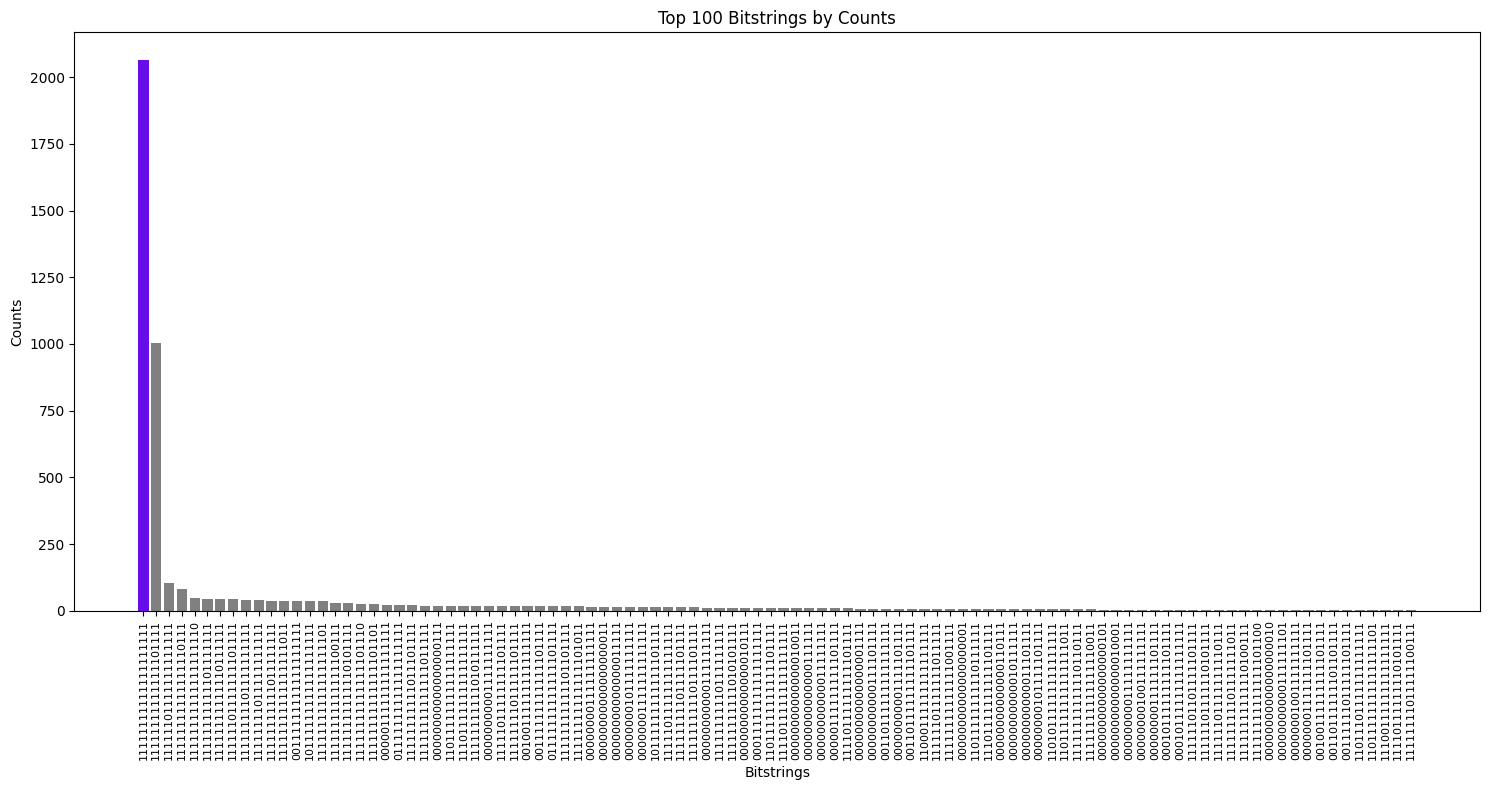

In [23]:
plot_top_bitstrings(counts, hidden_bitstring)

#### Optional: Compare Fire Opal to IBM Qiskit Runtime

If you are seeking a comparison, you may run the same program using Qiskit, without realizing the error suppression benefits Fire Opal includes. The code below uses Qiskit on the same IBM backend as previously to obtain this one-to-one comparison. Note that this job too is subject to the device queue and therefore may take anywhere from seconds to potentially hours.

In [24]:
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
)
backend = service.backend(backend_name)
sampler = Sampler(backend)

pass_manager = generate_preset_pass_manager(backend=backend)
isa_circuit = pass_manager.run(bv_circuit)

In [25]:
ibm_sampler_job = sampler.run([isa_circuit], shots=shot_count)

<a id="tips"></a>
<div class="alert alert-block alert-info">
    
<b> Tips:</b> 

* Check your IBM job's [status](https://quantum.cloud.ibm.com/docs/en/guides/monitor-job#monitor-a-job) or return [results](https://quantum.cloud.ibm.com/docs/en/guides/monitor-job#monitor-a-job) with: `ibm_sampler_job.status()`
    
</div>

In [26]:
# Retrieve the job results
ibm_sampler_result = ibm_sampler_job.result()

In [27]:
# Get results for the first (and only) PUB
ibm_pub_result = ibm_sampler_result[0]
ibm_counts = ibm_pub_result.data.c.get_counts()

if hidden_bitstring not in ibm_counts:
    print("The hidden_bitstring has 0% probability.")
else:
    print(
        f"Success probability: {(100 * ibm_counts.get(hidden_bitstring, 0) / shot_count):.2f}%"
    )

Success probability: 26.62%


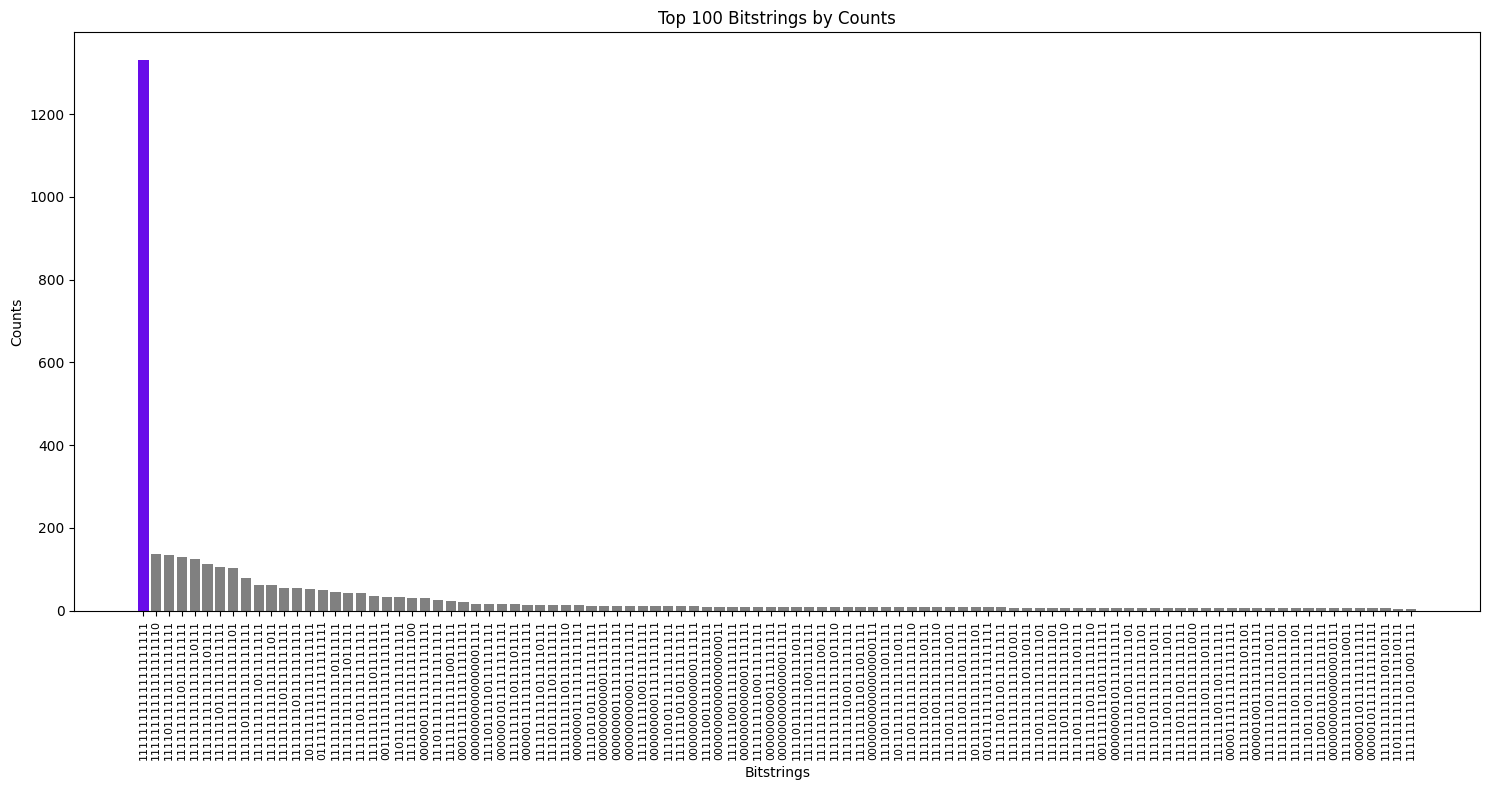

In [28]:
# Plot the top bitstrings for comparison
plot_top_bitstrings(ibm_counts, hidden_bitstring)

<a id="exercise2"></a>
<div class="alert alert-block alert-success">

<b> Exercise 2: Try out Estimator primitive.</b>

</div>

Use Fire Opal Performance Management's Estimator primitive to determine the expectation value of a single circuit-observable pair.

In addition to the `qiskit-ibm-catalog` and `qiskit` packages, you will also use the numpy package to run this example. You can install this package by uncommenting the following cell if you are running this example in a notebook using the IPython kernel.

#### 1. Create the circuit

The Estimator has efficient grouping of observables - it tries to minimize the number of circuits sent for execution, by grouping qubit-wise commuting observables together.

Commuting observables are quantum operators (represented here as Pauli strings) that can be measured together because the order in which you apply them doesn’t matter - their measurements don’t interfere with each other. Mathematically, two observables `A` and `B` commute if `AB = BA`.

For example, the Pauli operators "Z" and "I" commute, so observables like "ZIII" and "IZIZ" commute with each other. This property allows quantum algorithms to group and measure them efficiently in a single circuit.

In the below exercise, try creating a circuit with `n_qubits`, and create a set of commuting observables using `SparsePauliOp`.

In [29]:
# ---- TODO: Exercise 2.1 ----

n_qubits = 4
seed = 1234
pauli_strings = ["ZIII", "IZII", "IIZI", "IIIZ", "ZZII", "IIZZ"]
coeffs = np.random.default_rng(seed).random(len(pauli_strings))
observable = SparsePauliOp(pauli_strings, coeffs)


# ---- End of TODO ----

In [30]:
# Create the estimator circuit and estimator PUB

mat = np.real(random_hermitian(n_qubits, seed=seed))
circuit = iqp(mat)

# Create PUB tuple
estimator_pubs = [(circuit, observable)]

Now try it out yourself in real-time by running the circuit in the below steps!

#### 2. Run the circuit
Run the circuit and optionally define the backend and number of shots.

In [31]:
# ---- TODO: Exercise 2.2 ----
# Create options for the Estimator function

options_ex2 = {
    'primitive': "estimator",
    'pubs': estimator_pubs,
    'backend_name': backend_name,
    'options': {
        'default_shots': shot_count
    },
}
# ---- End of TODO ---

In [32]:
# Check your answer using following code
grade_ex2(n_qubits, observable, options_ex2)

'Congratulations! 🎉 Your answer is correct.'

<div class="alert alert-block alert-warning">

**⚠️ Warning: QPU Time Consumption**

Running the cell below will submit a job to a QPU and consume real QPU time. Please ensure you intend to proceed.

**Estimated QPU runtime:** 17 seconds (based on tests on `ibm_fez`)

</div>

In [33]:
# Run the circuit using the estimator

qctrl_estimator_job = perf_mgmt.run(**options_ex2)

<a id="tips"></a>
<div class="alert alert-block alert-info">
    
<b> Tips:</b> 

* Check your Qiskit Function workload's [status](https://quantum.cloud.ibm.com/docs/en/guides/functions#check-job-status) or return [results](https://quantum.cloud.ibm.com/docs/en/guides/functions#retrieve-results) with: `qctrl_estimator_job.status()`
    
</div>

In [39]:
qctrl_estimator_job.status()

'DONE'

#### 3. Retrieve the result

In [40]:
# Retrieve the counts from the result list
result = qctrl_estimator_job.result()

The results have the same format as an [Estimator result](https://docs.quantum.ibm.com/guides/primitive-input-output#estimator-output):

In [41]:
print(
    f"The result of the submitted job had {len(result)} PUB and has a value:\n {result}\n"
)
print(
    f"The associated PubResult of this job has the following DataBins:\n {result[0].data}\n"
)
print(f"And this DataBin has attributes: {result[0].data.keys()}")
print(
    f"The expectation values measured from this PUB are: \n{result[0].data.evs}"
)

The result of the submitted job had 1 PUB and has a value:
 PrimitiveResult([PubResult(data=DataBin(evs=2.489904985992771, stds=0.4842028972964808), metadata={'precision': None})], metadata={})

The associated PubResult of this job has the following DataBins:
 DataBin(evs=2.489904985992771, stds=0.4842028972964808)

And this DataBin has attributes: dict_keys(['evs', 'stds'])
The expectation values measured from this PUB are: 
2.489904985992771


<br> <br> <hr/>

# Feedback Survey

We’d love to hear about your experience using the Qiskit Function! Your feedback is valuable and will help Qiskit Function providers enhance their tools and services. Please take a moment to share your thoughts by completing our short 2 min [feedback survey](https://airtable.com/app6VujlNUHZuOnAF/pagpw6TgP9UEt4TAT/form).

# Get support
For any questions or issues, contact the Q-CTRL team at [support@q-ctrl.com](mailto:support@q-ctrl.com?subject=QGSS:%20requesting%20support).

# References

1. Learn more with [Q-CTRL's Performance Management function documentation](https://docs.quantum.ibm.com/guides/q-ctrl-performance-management)
2. For a detailed summary of the full Optimization Solver workflow, refer to the [published paper](https://journals.aps.org/prapplied/abstract/10.1103/PhysRevApplied.20.024034).
3. Learn more about the underlying technology at [Q-CTRL Fire Opal](https://q-ctrl.com/fire-opal).

# Additional information

**Created by:** Alex Shih, You Quan Chong

**Advised by:** Junye Huang

**Version:** 1.1.0

# Qiskit packages versions

In [ ]:
import qiskit
import qiskit_ibm_catalog

print(f'Qiskit: {qiskit.__version__}')
print(f'Qiskit IBM Catalog: {qiskit_ibm_catalog.__version__}')